In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("microplastic_polymer_cleaned.csv")

display(df)

,Polymer_Code,Polymer_Name,Common_Sources,Toxicity_Score,Degradation_Rate_Years,Number_of_Sources
0,PE,Polyethylene,"Plastic bags, bottles, packaging",3,450,3
1,PP,Polypropylene,"Bottle caps, food containers",2,500,2
2,PET,Polyethylene Terephthalate,"Beverage bottles, synthetic clothing",4,450,2
3,PS,Polystyrene,"Foam cups, insulation, packaging",7,500,3
4,PVC,Polyvinyl Chloride,"Pipes, credit cards, medical tubing",9,1000,3
5,PA,Polyamide (Nylon),"Synthetic textiles, fishing nets",5,40,2


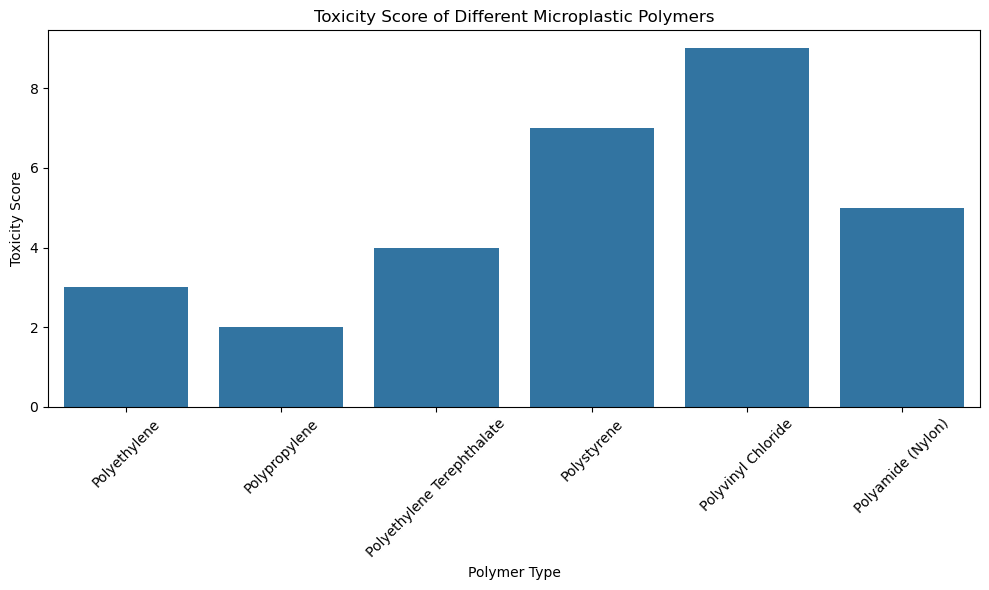

In [2]:
#Toxicity score of different polymers
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="Polymer_Name",
    y="Toxicity_Score"
)

plt.title("Toxicity Score of Different Microplastic Polymers")
plt.xlabel("Polymer Type")
plt.ylabel("Toxicity Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

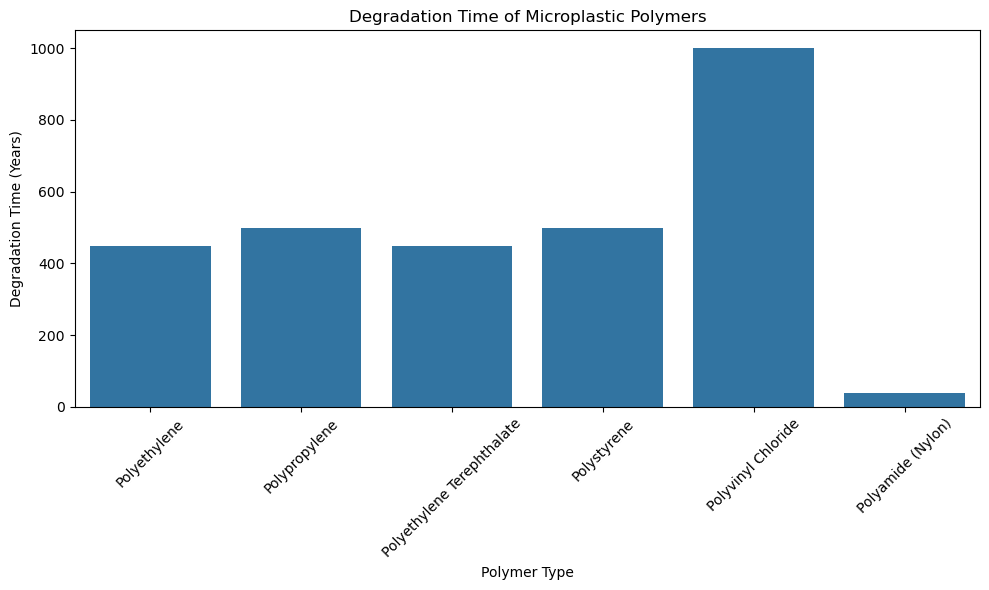

In [3]:
#Degradation time comparison
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="Polymer_Name",
    y="Degradation_Rate_Years"
)

plt.title("Degradation Time of Microplastic Polymers")
plt.xlabel("Polymer Type")
plt.ylabel("Degradation Time (Years)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

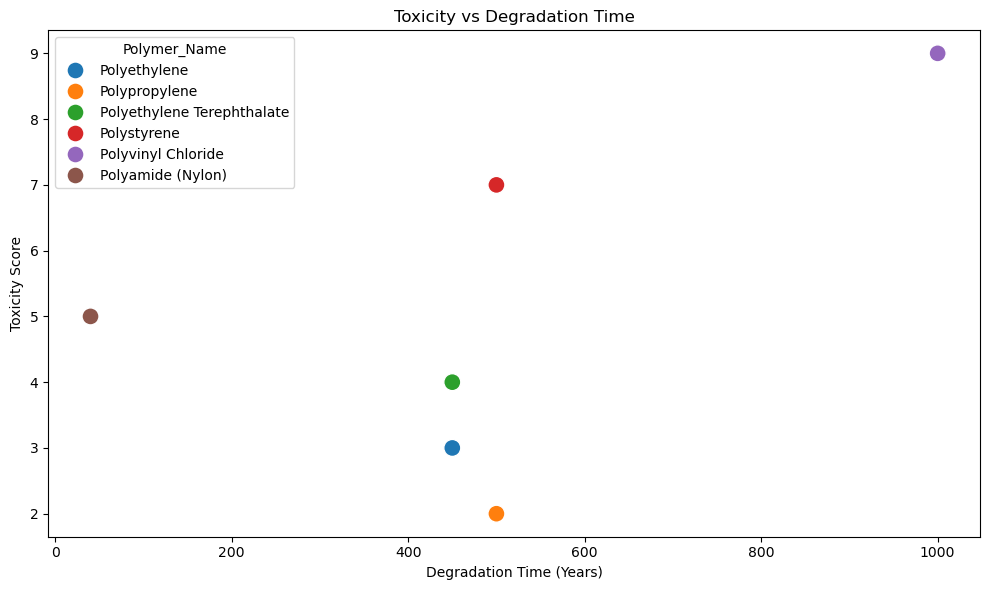

In [4]:
#Toxicity vs degradation time
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Degradation_Rate_Years",
    y="Toxicity_Score",
    hue="Polymer_Name",
    s=150
)

plt.title("Toxicity vs Degradation Time")
plt.xlabel("Degradation Time (Years)")
plt.ylabel("Toxicity Score")
plt.tight_layout()
plt.show()

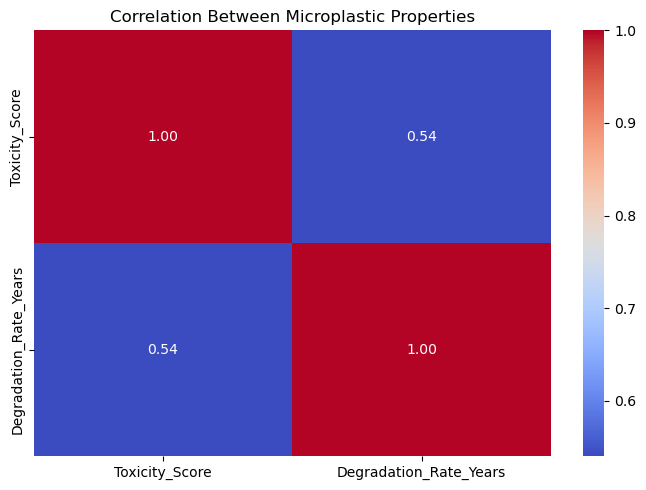

In [5]:
#Correlation heatmap
plt.figure(figsize=(7, 5))

corr = df[
    ["Toxicity_Score", "Degradation_Rate_Years"]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Microplastic Properties")
plt.tight_layout()
plt.show()

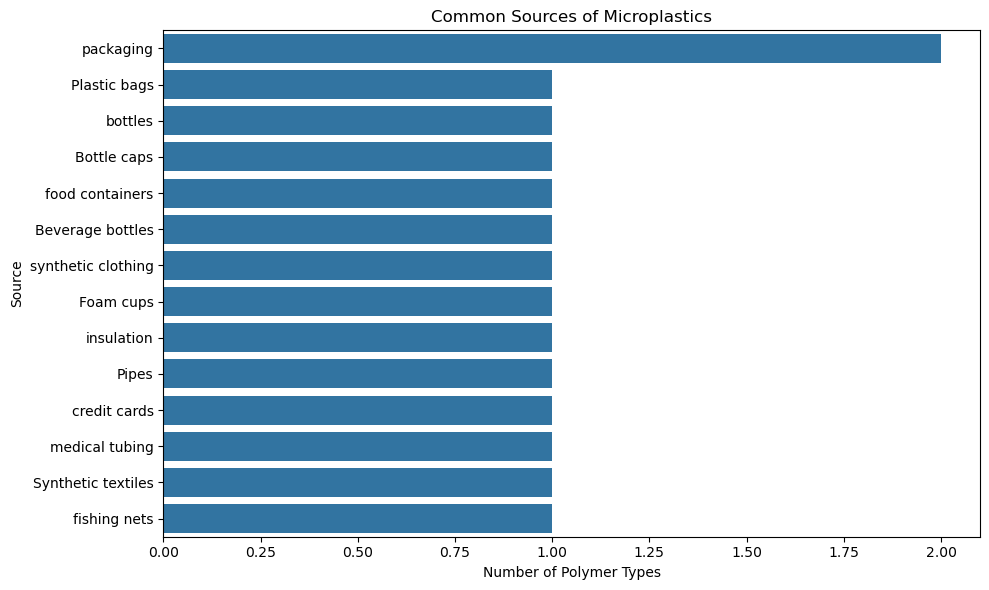

In [6]:
#Common sources of microplastics
sources = (
    df["Common_Sources"]
    .str.split(",")
    .explode()
    .str.strip()
)

source_counts = sources.value_counts()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=source_counts.values,
    y=source_counts.index
)

plt.title("Common Sources of Microplastics")
plt.xlabel("Number of Polymer Types")
plt.ylabel("Source")

plt.tight_layout()
plt.show()

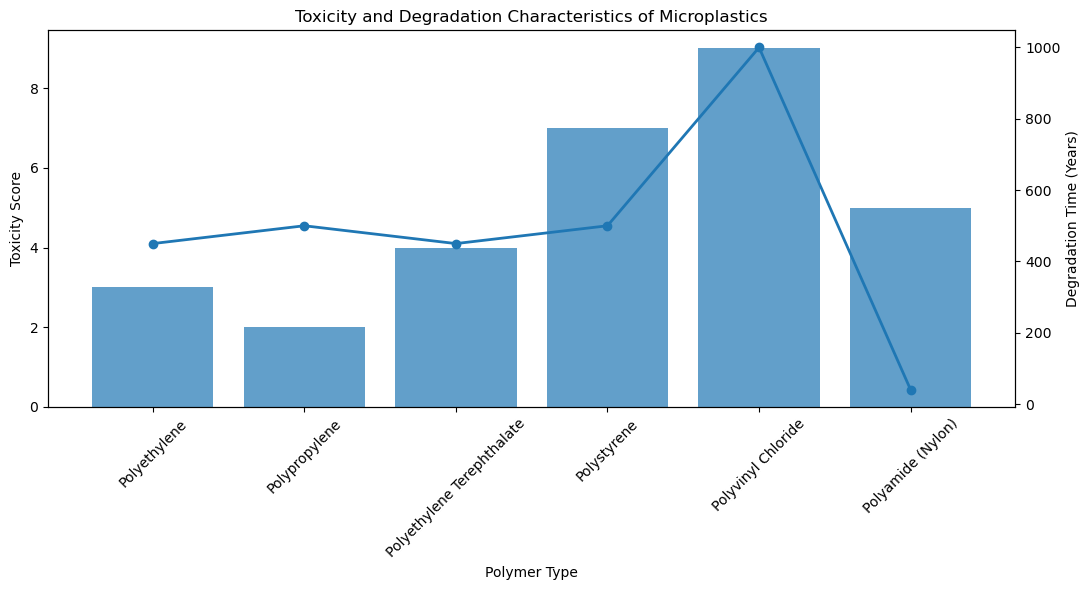

In [7]:
#Combined toxicity and degradation view
fig, ax1 = plt.subplots(figsize=(11, 6))

ax1.bar(
    df["Polymer_Name"],
    df["Toxicity_Score"],
    alpha=0.7,
    label="Toxicity Score"
)

ax1.set_xlabel("Polymer Type")
ax1.set_ylabel("Toxicity Score")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()

ax2.plot(
    df["Polymer_Name"],
    df["Degradation_Rate_Years"],
    marker="o",
    linewidth=2,
    label="Degradation Time"
)

ax2.set_ylabel("Degradation Time (Years)")

plt.title("Toxicity and Degradation Characteristics of Microplastics")
plt.tight_layout()
plt.show()